In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [2]:
# Import AwsDataHandler to get the data from aws
from aws_handler import AwsDataHandler

# get the path/file from aws
data_handler = AwsDataHandler(aws_file_path='data/predictive-maintenance/clean_data/clean_data.parquet')
aws_path = data_handler.get_data_from_aws()


# local_path = 'data/aircraft engine/PM_train.parquet'
df = pd.read_parquet(aws_path)
df.head()

connecting to:  s3://aws-s3-data-for-projects/data/predictive-maintenance/clean_data/clean_data.parquet


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21,max,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [3]:
unique_col = []
for i in df.columns.tolist():
    print(i, ': ', df[i].nunique())
    if df[i].nunique() == 1:
        unique_col.append(i)

id :  100
cycle :  362
setting1 :  158
setting2 :  13
setting3 :  1
s1 :  1
s2 :  310
s3 :  3012
s4 :  4051
s5 :  1
s6 :  2
s7 :  513
s8 :  53
s9 :  6403
s10 :  1
s11 :  159
s12 :  427
s13 :  56
s14 :  6078
s15 :  1918
s16 :  1
s17 :  13
s18 :  1
s19 :  1
s20 :  120
s21 :  4745
max :  66
RUL :  362


In [4]:
unique_col

['setting3', 's1', 's5', 's10', 's16', 's18', 's19']

# many col has only one unique value

In [5]:
# s6 only col which has 2  unique value
df.s6.describe()

count    20631.000000
mean        21.609803
std          0.001389
min         21.600000
25%         21.610000
50%         21.610000
75%         21.610000
max         21.610000
Name: s6, dtype: float64

In [6]:
# the values are float and diff is just 0.01 ???

df_s6_21_6 = df[df.s6==21.6]

In [7]:
df_s6_21_61 = df[df.s6==21.61]

In [8]:
df_s6_21_61.id.nunique()

100

In [9]:
# print('df_s6_21_6')
# for i in df_s6_21_6.columns.tolist():
#     print(i, ': ', df_s6_21_6[i].nunique())

df_s6_21_6.id.unique()

array([  2,   3,   4,   5,   7,   9,  10,  11,  15,  17,  18,  21,  24,
        27,  28,  30,  31,  33,  34,  41,  42,  43,  44,  45,  46,  47,
        48,  50,  51,  52,  53,  54,  57,  59,  61,  64,  65,  66,  67,
        68,  69,  72,  74,  77,  78,  79,  81,  82,  83,  85,  86,  88,
        89,  90,  92,  93,  95,  96,  97,  98,  99, 100])

# only this id's have s6 == 21.6 this might create a bias in model training

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
unique_col

['setting3', 's1', 's5', 's10', 's16', 's18', 's19']

[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]


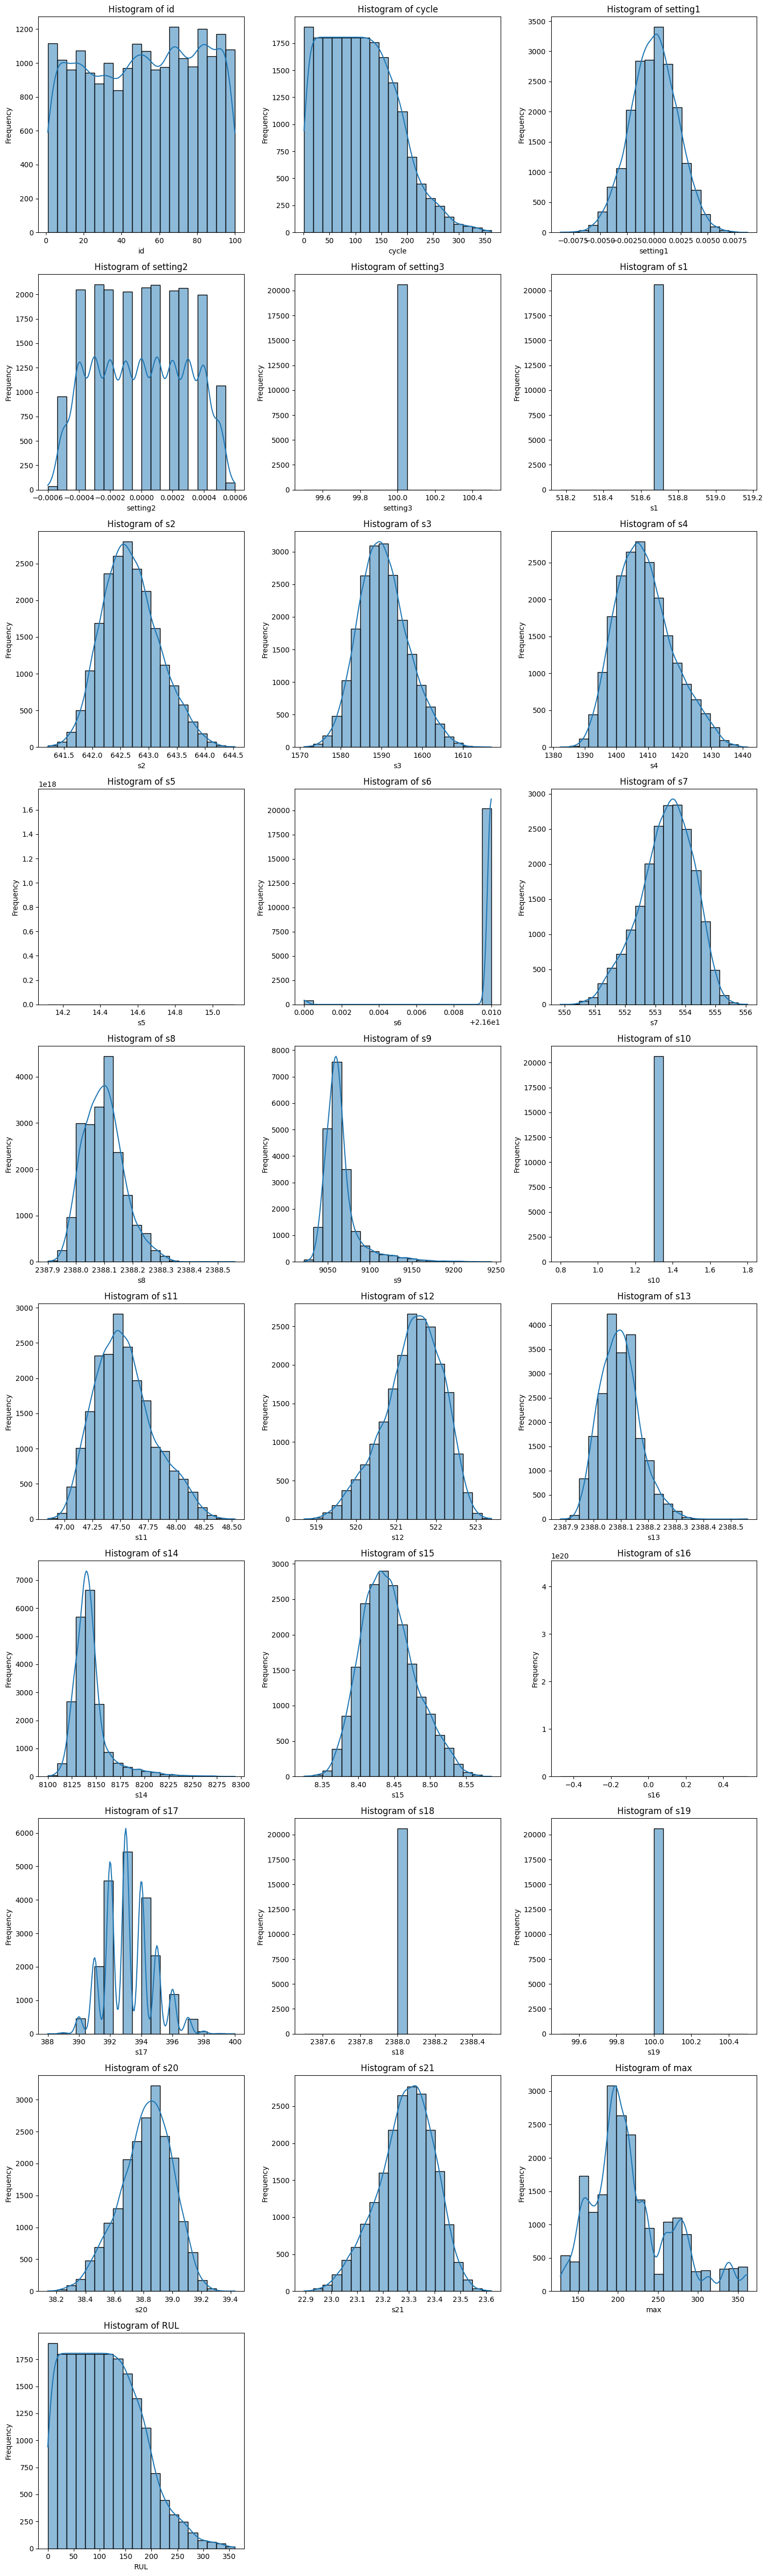

In [12]:
# Define number of rows and columns for subplots

num_cols = df.shape[1]
rows = (num_cols // 3) + (num_cols % 3 > 0)  # Arrange in 3 columns

# Create subplots
fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))  # Adjust figure size dynamically

# Flatten axes array for easy iteration
axes = axes.flatten()
# print(axes)

# Loop through each column and plot
for i, col in enumerate(df.columns):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()